In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('data_science_job.csv')

In [4]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [6]:
df.shape

(19158, 13)

In [5]:
df.isnull().sum()  #df.isnull() converts df into true or false values.

enrollee_id                  0
city                         0
city_development_index     479
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
training_hours             766
target                       0
dtype: int64

In [7]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [9]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
# include var in columns if it satisfies that condition

In [10]:
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [13]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
17225,0.691,no_enrollment,Graduate,15.0,45.0
4703,0.910,no_enrollment,Masters,15.0,112.0
2706,0.827,no_enrollment,Masters,7.0,48.0
2229,0.827,Full time course,High School,7.0,77.0
1615,0.920,no_enrollment,Masters,20.0,15.0


In [14]:
len(df[cols].dropna())/len(df) #to get % of rows retained 

0.8968577095730244

In [16]:
new_df = df[cols].dropna()
new_df.shape

(17182, 5)

In [17]:
df.shape

(19158, 13)

array([[<Axes: title={'center': 'city_development_index'}>,
        <Axes: title={'center': 'experience'}>],
       [<Axes: title={'center': 'training_hours'}>, <Axes: >]],
      dtype=object)

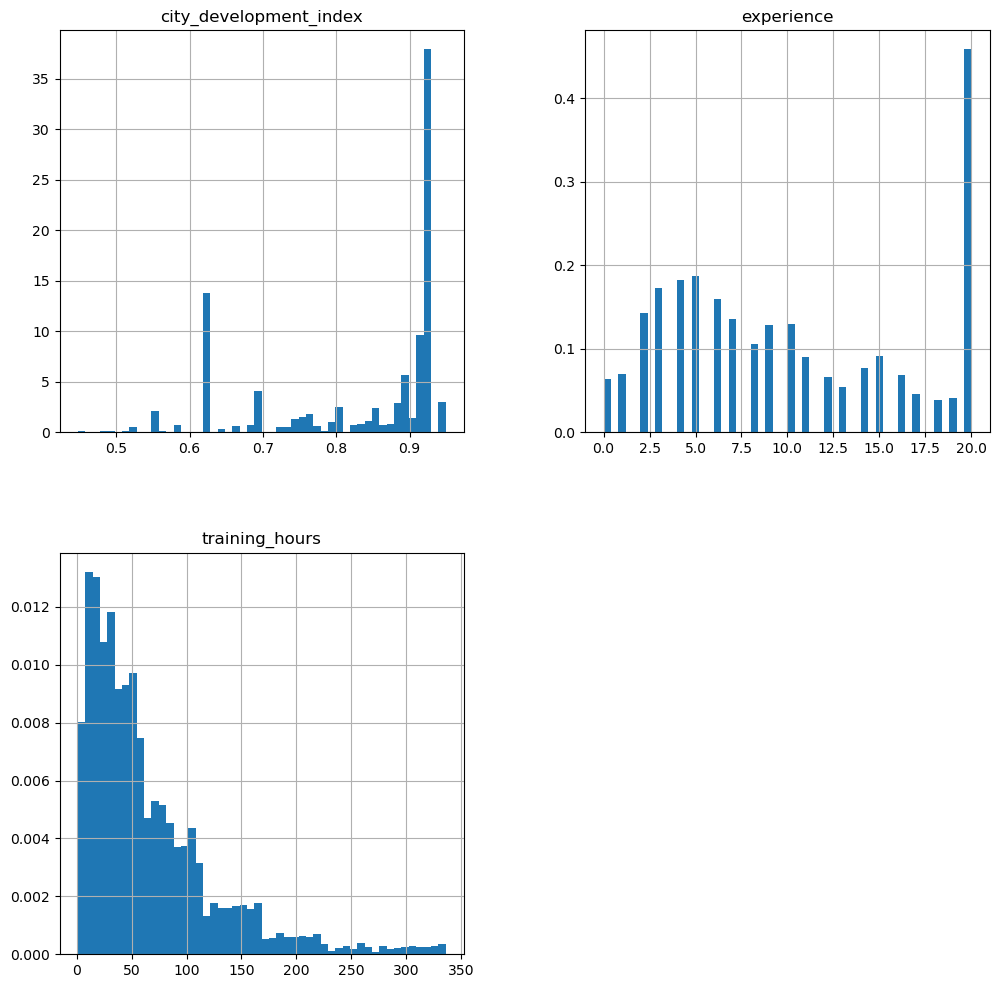

In [18]:
new_df.hist(bins=50, density=True, figsize=(12,12))

In [22]:
temp = pd.concat([ df['enrolled_university'].value_counts()/len(df) ,
                   new_df['enrolled_university'].value_counts()/len(new_df)]
                   ,axis=1)
temp.columns = ['original','after cca']
# percentage of each category in 'enrolled_university' column before and after removing
#if there is no much change in percentage, we can do CCA on these column
temp

,original,after cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [23]:
temp = pd.concat([ df['education_level'].value_counts()/len(df),
                   new_df['education_level'].value_counts()/len(new_df)],
                   axis=1)
temp.columns = ['original','after cca']
temp

,original,after cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
